# 06 - EMBEDDINGS, PCA ET REDUCTION DE DIMENSION

Suite du Module 2 -- *Apprendre à comparer*. On reprend le même corpus annoté et on construit cette fois des représentations sémantiques par embeddings, qu'on visualise dans un espace 2D.

**Plan**

1. **Embeddings de mots** : on entraîne un Word2Vec sur le corpus, et on charge un fastText pré-entrainé sur Common Crawl français pour comparer.
2. **Vecteurs de livres** : pour chaque livre, on agrège les vecteurs de mots de deux manières (moyenne simple, moyenne pondérée TF-IDF).
3. **Reduction 2D** : PCA implémentée à la main + t-SNE + UMAP pour visualiser le corpus.
4. **Benchmark** : on rejoue le protocole TF-IDF mais avec les embeddings.

## Setup

In [1]:
import sys
from pathlib import Path

# Se déplacer dans le dossier du projet (NE LANCER Q'UNE FOIS)
%cd ../
%ls

/home/gau/projets/nlp/projet_nlp_app
README.md  figures/  notebooks/      pipeline/         scripts/
app/       models/   pg_catalog.csv  requirements.txt


In [2]:
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import KeyedVectors, Word2Vec
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
import umap

from pipeline.config import BENCH_PARAMS, W2V_PARAMS
from pipeline.corpus import charger_corpus
from pipeline.representations import calculer_idf, cosinus, vecteur_livre_embeddings

CFG = {
    "figures_dir":         Path("figures"),
    "models_dir":          Path("models"),
    "n_extraits_par_livre": BENCH_PARAMS["n_extraits_par_livre"],
    "taille_extrait":      BENCH_PARAMS["taille_extrait"],
    "seed":                BENCH_PARAMS["seed"],
}
CFG["figures_dir"].mkdir(exist_ok=True)
CFG["models_dir"].mkdir(exist_ok=True)
rng = np.random.default_rng(CFG["seed"])

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

## Chargement

In [3]:
corpus = charger_corpus()

Chargement de 26 livres annotes...
  26 livres charges


## Construction des phrases pour Word2Vec

Word2Vec apprend les associations dans des fenêtres glissantes autour de chaque mot. Pour que la fenêtre n'enjambe pas les frontières de phrases, on découpe le corpus en phrases via le `sent_id` produit par spaCy. Filtres habituels : alphabetiques, hors stopwords, hors ponctuation.


In [4]:
phrases_w2v = []
for c in corpus:
    df = c["df"]
    masque = df["is_alpha"] & ~df["is_stop"] & ~df["is_punct"]
    sub = df.loc[masque, ["sent_id", "lemma"]].copy()
    sub["lemma"] = sub["lemma"].str.lower()
    for _, groupe in sub.groupby("sent_id"):
        if len(groupe) >= 3:
            phrases_w2v.append(groupe["lemma"].tolist())

print(f"{len(phrases_w2v):,} phrases pour entrainer Word2Vec")
print(f"Exemple : {phrases_w2v[100][:15]}")

101,436 phrases pour entrainer Word2Vec
Exemple : ['faire', 'mettre', 'cheval']


## Embeddings 1 : Word2Vec entrainé sur le corpus

Word2Vec **skip-gram** (`sg=1`) avec une dimension de 100, fenêtre de 5 mots, et 10 époques.


In [5]:
t0 = time.time()
w2v = Word2Vec(
    sentences=phrases_w2v,
    vector_size=W2V_PARAMS["vector_size"],
    window=W2V_PARAMS["window"],
    min_count=W2V_PARAMS["min_count"],
    sg=W2V_PARAMS["sg"],
    workers=W2V_PARAMS["workers"],
    epochs=W2V_PARAMS["epochs"],
    seed=W2V_PARAMS["seed"],
)
duree = time.time() - t0

print(f"Entrainement Word2Vec : {duree:.1f}s")
print(f"Vocabulaire : {len(w2v.wv):,} mots")
print(f"Dimension   : {w2v.wv.vector_size}")

for mot in ["musique", "guerre", "amour", "navire"]:
    if mot in w2v.wv:
        voisins = w2v.wv.most_similar(mot, topn=5)
        voisins_str = ", ".join(f"{v} ({s:.2f})" for v, s in voisins)
        print(f"  voisins de '{mot}' : {voisins_str}")


Entrainement Word2Vec : 9.0s
Vocabulaire : 18,159 mots
Dimension   : 100
  voisins de 'musique' : accompagnement (0.76), maestro (0.76), cantilène (0.75), mélodie (0.75), buffa (0.75)
  voisins de 'guerre' : turcs (0.66), civil (0.64), fomenter (0.63), réclamation (0.63), vassal (0.63)
  voisins de 'amour' : tendresse (0.65), débordement (0.64), joconde (0.63), inspiration (0.63), exaltation (0.63)
  voisins de 'navire' : ourque (0.81), matutina (0.77), tartane (0.76), pilote (0.75), barque (0.75)


## Embeddings 2 : fastText pre-entrainé (Common Crawl français)

Le modèle `cc.fr.300` de Facebook fastText est entrainé sur du français général. Il connait plus de mots que notre Word2Vec et capture la sémantique générale du français.

Premier run : téléchargement de ~700 Mo. Mis en cache localement, runs suivants instantanés. Si pas de connexion, on bascule en mode Word2Vec uniquement.


In [6]:
fasttext_path = CFG["models_dir"] / "cc.fr.300.vec"
fasttext_gz_path = CFG["models_dir"] / "cc.fr.300.vec.gz"
fasttext_url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz"

GARDER_GZ = False
ft = None

try:
    if not fasttext_path.exists():
        if not fasttext_gz_path.exists():
            print("Telechargement de fastText cc.fr.300 (~1.3 Go compresse)...")
            urllib.request.urlretrieve(fasttext_url, fasttext_gz_path)
            print(f"  -> {fasttext_gz_path.stat().st_size / 1024**3:.2f} Go")

        import gzip, shutil
        tmp_path = fasttext_path.with_suffix(".vec.tmp")
        print("Decompression...")
        with gzip.open(fasttext_gz_path, "rb") as fin, open(tmp_path, "wb") as fout:
            shutil.copyfileobj(fin, fout)
        tmp_path.replace(fasttext_path)
        print(f"  -> {fasttext_path.stat().st_size / 1024**3:.2f} Go")

        if not GARDER_GZ and fasttext_gz_path.exists():
            fasttext_gz_path.unlink()

    print("\nChargement en memoire (peut prendre 1-2 min)...")
    t0 = time.time()
    ft = KeyedVectors.load_word2vec_format(str(fasttext_path), binary=False)
    print(f"Charge en {time.time()-t0:.0f}s : {len(ft):,} mots, dim {ft.vector_size}")

    for mot in ["musique", "guerre", "amour", "navire"]:
        if mot in ft:
            voisins = ft.most_similar(mot, topn=5)
            voisins_str = ", ".join(f"{v} ({s:.2f})" for v, s in voisins)
            print(f"  voisins de '{mot}' : {voisins_str}")

except Exception as e:
    print(f"Echec du chargement fastText : {e}")
    print("Le notebook continue avec Word2Vec uniquement.")



Chargement en memoire (peut prendre 1-2 min)...
Charge en 316s : 2,000,000 mots, dim 300
  voisins de 'musique' : musiques (0.73), Musique (0.73), musicale (0.71), musique. (0.71), musique.La (0.70)
  voisins de 'guerre' : Guerre (0.80), guerrre (0.74), guerres (0.72), guerre.La (0.70), -guerre (0.70)
  voisins de 'amour' : Amour (0.76), amour. (0.72), amour.L (0.69), amour.Il (0.68), amour.Un (0.68)
  voisins de 'navire' : bateau (0.78), paquebot (0.74), navire. (0.74), navires (0.74), voilier (0.74)


## Agrégation : du vecteur de mot au vecteur de livre

Deux stratégies, factorisés dans `pipeline.representations.vecteur_livre_embeddings` :

- **Moyenne simple.** v_d = (1/|d|) sum_w v_w
- **Moyenne ponderee TF-IDF.** v_d = sum_w tfidf(w,d) v_w / sum_w tfidf(w,d)


In [7]:
idf_corpus = calculer_idf([c["lemmes"] for c in corpus])
print(f"IDF calcule sur {len(idf_corpus):,} termes")

matrices = {}
sources = {"w2v": w2v.wv}
if ft is not None:
    sources["fasttext"] = ft

for nom_source, vecs in sources.items():
    for nom_agg, idf in [("moyenne", None), ("tfidf", idf_corpus)]:
        cle = f"{nom_source}_{nom_agg}"
        M = np.array([vecteur_livre_embeddings(c["lemmes"], vecs, idf=idf) for c in corpus])
        matrices[cle] = M
        couverture = np.array([
            sum(1 for t in c["lemmes"] if t in vecs) / len(c["lemmes"])
            for c in corpus
        ]).mean()
        print(f"  {cle:25s} : matrice {M.shape}, couverture moyenne = {couverture:.1%}")


IDF calcule sur 38,858 termes
  w2v_moyenne               : matrice (26, 100), couverture moyenne = 96.9%
  w2v_tfidf                 : matrice (26, 100), couverture moyenne = 96.9%
  fasttext_moyenne          : matrice (26, 300), couverture moyenne = 96.3%
  fasttext_tfidf            : matrice (26, 300), couverture moyenne = 96.3%


## PCA implementée à la main

1. **Centrage** : Xc = X - mean(X)
2. **SVD** : Xc = U Sigma V^T (numeriquement plus stable que la décomposition propre de la matrice de covariance, surtout quand le nombre de features est grand)
3. **Projection** sur les k premieres directions : Y = Xc V_:k
4. **Variance expliquée** : sigma_i^2 / (n-1), normalisee par la variance totale.

On valide en comparant la variance expliquée et les distances paire-à-paire à celles de sklearn.


In [8]:
class PCAMaison:
    """PCA from scratch via SVD. API minimale : fit_transform."""

    def __init__(self, n_components):
        self.n_components = n_components

    def fit_transform(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        self.components_ = Vt[:self.n_components]
        n = X.shape[0]
        self.explained_variance_ = (S ** 2) / (n - 1)
        total = self.explained_variance_.sum()
        self.explained_variance_ratio_ = self.explained_variance_[:self.n_components] / total
        return Xc @ self.components_.T


In [9]:
from scipy.spatial.distance import pdist

X_test = list(matrices.values())[0]

pca_maison = PCAMaison(n_components=2)
Y_maison = pca_maison.fit_transform(X_test)
pca_sk = SklearnPCA(n_components=2, random_state=42)
Y_sk = pca_sk.fit_transform(X_test)

print("Variance expliquee maison  :", np.round(pca_maison.explained_variance_ratio_, 4))
print("Variance expliquee sklearn :", np.round(pca_sk.explained_variance_ratio_, 4))

# Trois invariants caracteristiques d'une PCA correcte :
ratios_egaux = np.allclose(
    pca_maison.explained_variance_ratio_,
    pca_sk.explained_variance_ratio_, atol=1e-10,
)
inerties_egales = np.allclose(np.sum(Y_maison**2, axis=1), np.sum(Y_sk**2, axis=1), atol=1e-6)
distances_egales = np.allclose(pdist(Y_maison), pdist(Y_sk), atol=1e-6)

print(f"\nVariance identique         : {ratios_egaux}")
print(f"Inertie de chaque point    : {inerties_egales}")
print(f"Distances entre points     : {distances_egales}")

assert ratios_egaux and inerties_egales and distances_egales
print("\nValidation OK.")
print()
print("Note : la PCA n'est unique qu'a rotation/reflexion pres des sous-espaces engendres")
print("par des valeurs singulieres egales ou tres proches. Sur ce corpus, les bases choisies")
print("par notre implementation et sklearn peuvent differer, mais les invariants geometriques")
print("(variance, inerties, distances) sont strictement identiques.")


Variance expliquee maison  : [0.4183 0.1424]
Variance expliquee sklearn : [0.4183 0.1424]

Variance identique         : True
Inertie de chaque point    : True
Distances entre points     : True

Validation OK.

Note : la PCA n'est unique qu'a rotation/reflexion pres des sous-espaces engendres
par des valeurs singulieres egales ou tres proches. Sur ce corpus, les bases choisies
par notre implementation et sklearn peuvent differer, mais les invariants geometriques
(variance, inerties, distances) sont strictement identiques.


## Visualisations 2D

PCA + t-SNE + UMAP côte à côte sur chaque matrice. Couleur par genre.


/home/gau/projets/nlp/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gau/projets/nlp/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gau/projets/nlp/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gau/projets/nlp/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


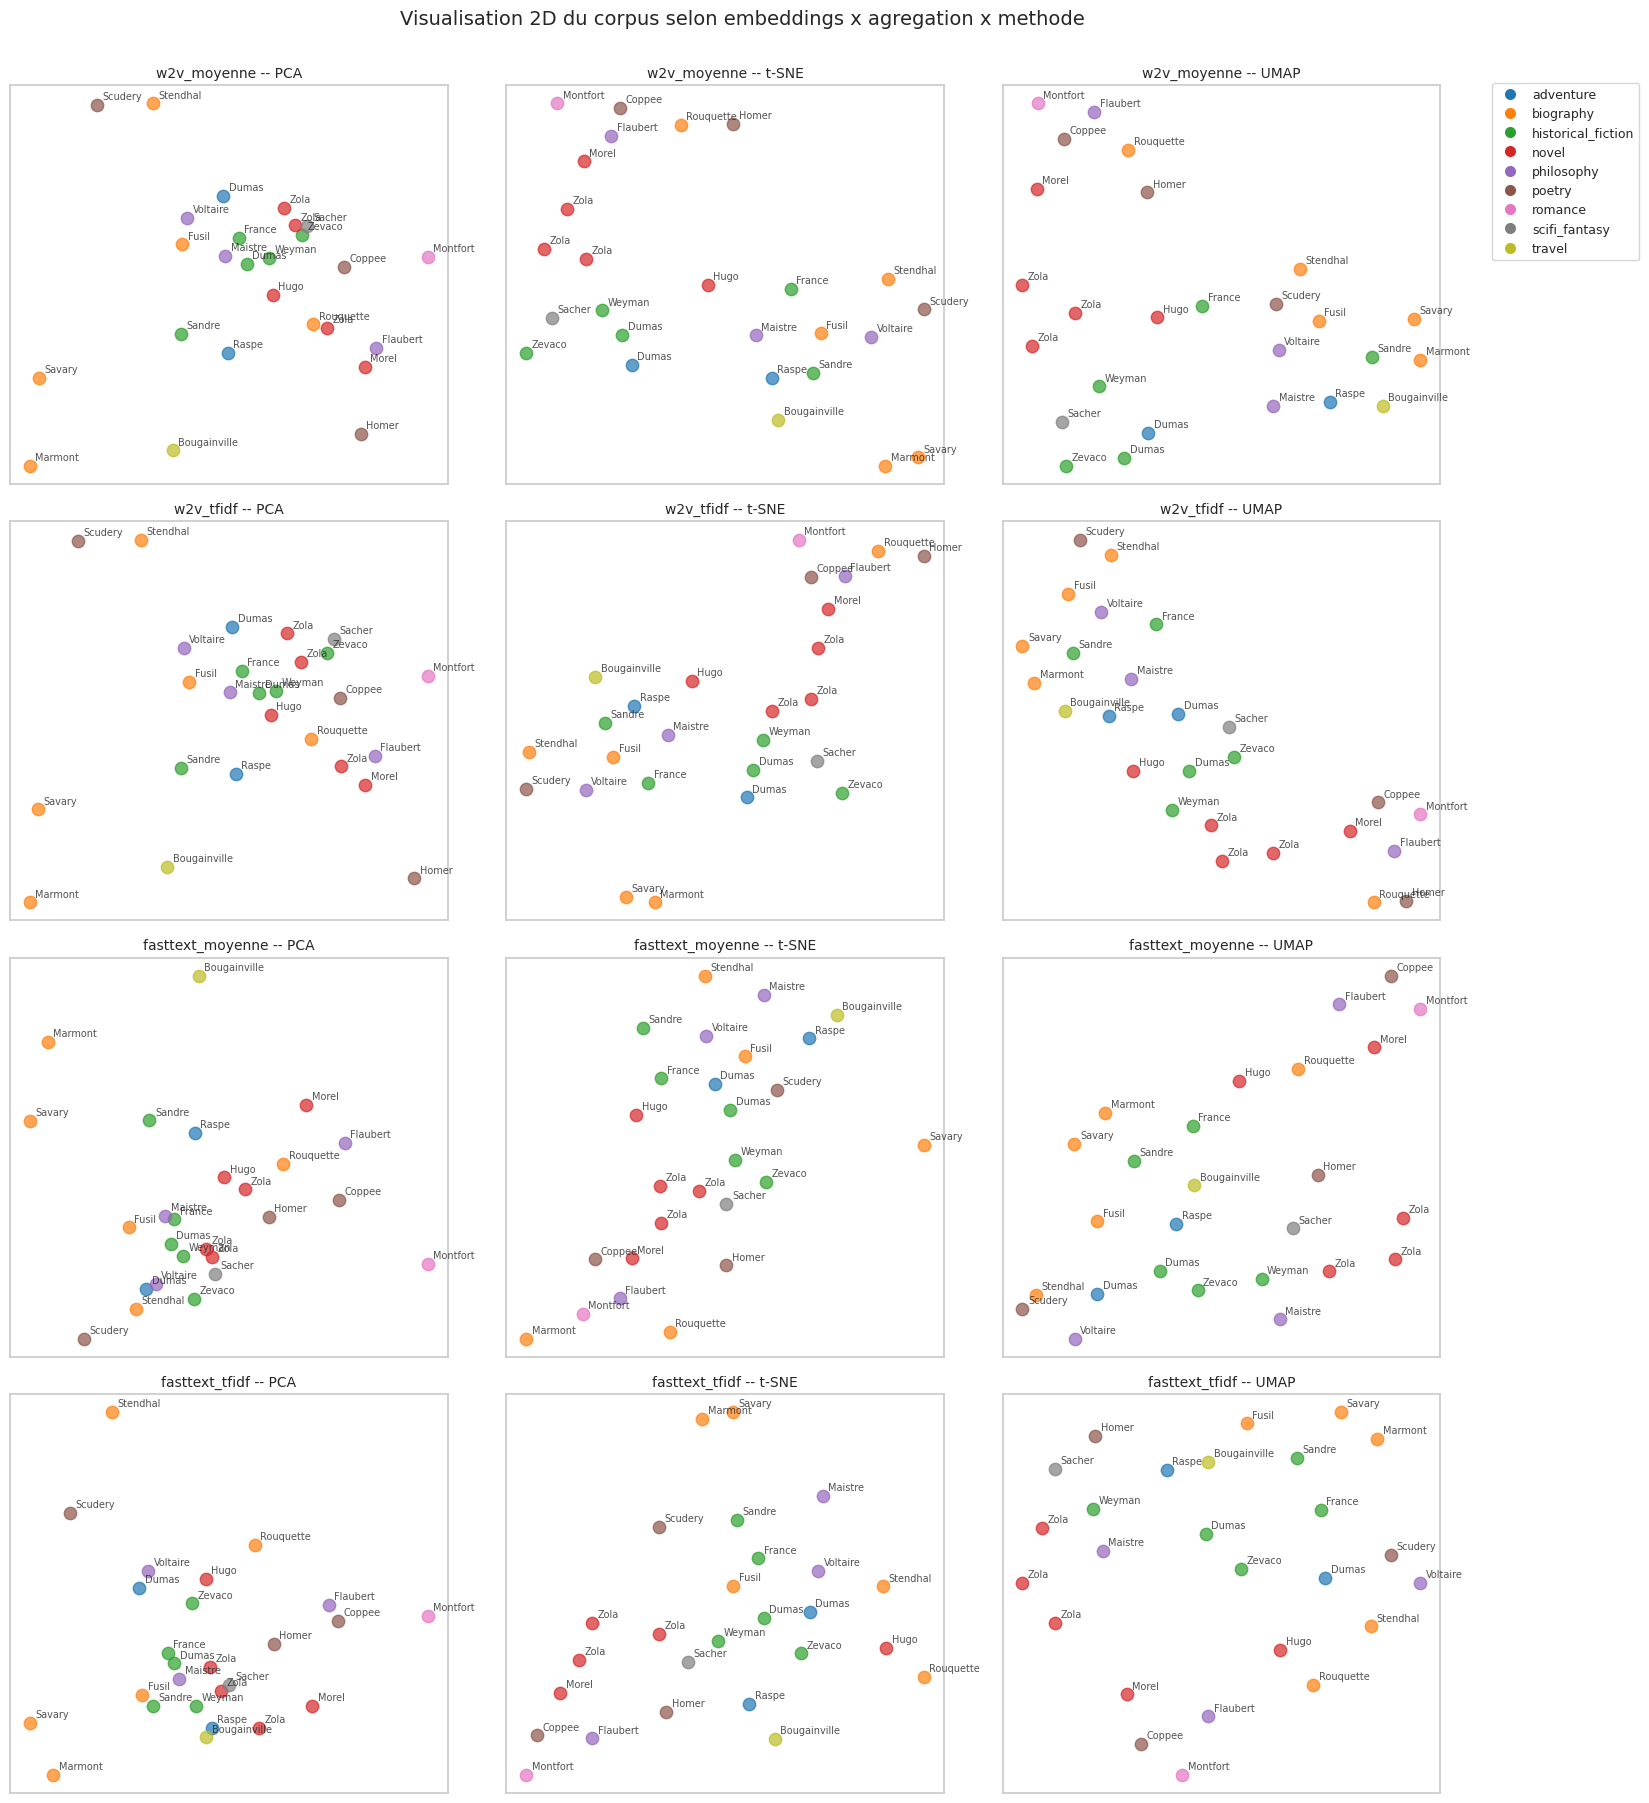

In [10]:
def reduire_2d(X, methode):
    if methode == "PCA":
        return PCAMaison(n_components=2).fit_transform(X)
    if methode == "t-SNE":
        return TSNE(n_components=2, perplexity=5, random_state=CFG["seed"],
                    init="pca", learning_rate="auto").fit_transform(X)
    if methode == "UMAP":
        return umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.3,
                        random_state=CFG["seed"]).fit_transform(X)
    raise ValueError(methode)

methodes = ["PCA", "t-SNE", "UMAP"]
matrices_keys = list(matrices.keys())
n_rows = len(matrices_keys)
n_cols = len(methodes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4.5))
if n_rows == 1:
    axes = axes[np.newaxis, :]

genres_uniques = sorted(set(c["genre"] for c in corpus))
couleurs = {g: c for g, c in zip(genres_uniques, plt.cm.tab10.colors)}

for i, cle in enumerate(matrices_keys):
    X = matrices[cle]
    for j, methode in enumerate(methodes):
        Y = reduire_2d(X, methode)
        ax = axes[i, j]
        for k, c in enumerate(corpus):
            ax.scatter(Y[k, 0], Y[k, 1], color=couleurs[c["genre"]], s=80, alpha=0.7)
            ax.annotate(c["auteur"].split()[0],
                        (Y[k, 0], Y[k, 1]),
                        xytext=(4, 4), textcoords="offset points",
                        fontsize=7, alpha=0.8)
        ax.set_title(f"{cle} -- {methode}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

handles = [plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=couleurs[g], markersize=9, label=g)
           for g in genres_uniques]
fig.legend(handles=handles, bbox_to_anchor=(1.0, 0.96), loc="upper left",
           borderaxespad=0, fontsize=9)

plt.suptitle("Visualisation 2D du corpus selon embeddings x agregation x methode",
             y=1.001, fontsize=14)
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "embeddings_2d_grille.png")
plt.show()


## Benchmark d'identification

On reproduit le protocole du notebook 05 (TF-IDF) avec les mêmes paramètres pour pouvoir comparer directement.


In [11]:
extraits = []
for i, c in enumerate(corpus):
    for _ in range(CFG["n_extraits_par_livre"]):
        n = len(c["lemmes"])
        if n <= CFG["taille_extrait"]:
            continue
        debut = rng.integers(0, n - CFG["taille_extrait"])
        extraits.append({
            "livre_idx": i,
            "source":    c["auteur"],
            "lemmes":    c["lemmes"][debut: debut + CFG["taille_extrait"]],
        })
print(f"{len(extraits)} extraits generes")


130 extraits generes


In [12]:
lignes_bench = []
for cle, M in matrices.items():
    nom_source, nom_agg = cle.split("_", 1)
    vecs = sources[nom_source]
    idf_use = idf_corpus if nom_agg == "tfidf" else None

    for ext in extraits:
        v_extrait = vecteur_livre_embeddings(ext["lemmes"], vecs, idf=idf_use)
        sims = np.array([cosinus(v_extrait, M[i]) for i in range(len(corpus))])
        ordre = np.argsort(-sims)
        rang = int(np.where(ordre == ext["livre_idx"])[0][0]) + 1
        lignes_bench.append({"config": cle, "livre_cible": ext["source"], "rang": rang})

bench = pd.DataFrame(lignes_bench)

tableau = (
    bench.groupby("config")
    .apply(lambda d: pd.Series({
        "top_1":       (d["rang"] == 1).mean() * 100,
        "top_3":       (d["rang"] <= 3).mean() * 100,
        "top_5":       (d["rang"] <= 5).mean() * 100,
        "MRR":         (1 / d["rang"]).mean(),
        "rang_median": d["rang"].median(),
    }), include_groups=False)
    .round(2)
    .sort_values("top_1", ascending=False)
)
tableau


,top_1,top_3,top_5,MRR,rang_median
config,,,,,
w2v_tfidf,81.54,92.31,95.38,0.88,1.0
fasttext_tfidf,79.23,93.08,93.85,0.86,1.0
w2v_moyenne,75.38,89.23,94.62,0.84,1.0
fasttext_moyenne,72.31,86.15,91.54,0.80,1.0


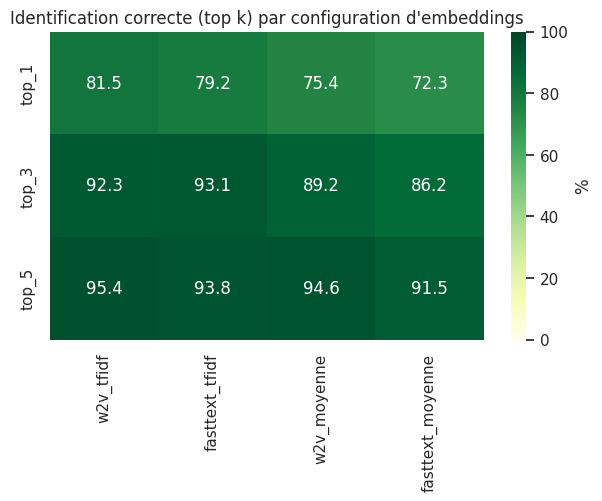

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
tableau_viz = tableau[["top_1", "top_3", "top_5"]].T
sns.heatmap(tableau_viz, annot=True, fmt=".1f", cmap="YlGn",
            cbar_kws={"label": "%"}, vmin=0, vmax=100, ax=ax)
ax.set_title("Identification correcte (top k) par configuration d'embeddings")
ax.set_xlabel("")
ax.set_ylabel("")
plt.savefig(CFG["figures_dir"] / "embeddings_benchmark.png")
plt.show()


## Conclusions

1. **Word2Vec vs fastText** -- fastText capture la sémantique générale du français (pre-entrainé sur des milliards de mots). Word2Vec local ne voit que ~1.5M de tokens mais capture la sémantique propre au corpus (l'association `rossini` <-> `musique` est très forte chez nous, faible chez fastText).
2. **Moyenne vs TF-IDF** -- la pondération TF-IDF réduit l'influence des mots frequents-mais-peu-discriminants. Effet net sur l'identification top 1 à observer dans le tableau ci-dessus.
3. **Embeddings vs TF-IDF du notebook 05** -- comparaison directe à faire dans le rapport. En général, sur du retrieval pur (extrait -> livre), TF-IDF reste très compétitif avec un corpus de cette taille.
